# Credit Card Fraud Detection


Hybrid MoE uses 5 reported experts: **LSTM, Transformer, Balance, Supervised Tabular, Autoencoder**.

Implementation note: the branch internally named `anomaly_expert` / `gate_anomaly` is the 39-feature supervised tabular branch, not the Autoencoder reconstruction-error branch.


## 1. Setup thư viện



In [1]:
import importlib.util
import subprocess
import sys

REQUIRED = {
    "numpy": "numpy", "pandas": "pandas", "sklearn": "scikit-learn",
    "matplotlib": "matplotlib", "seaborn": "seaborn",
    "xgboost": "xgboost", "tensorflow": "tensorflow",
}
missing = [pkg for module, pkg in REQUIRED.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import gc
import json
import os
import pickle
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from tensorflow import keras
from tensorflow.keras import layers
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.21.0
GPU: []


## 2. Đường dẫn, seed và cấu hình



In [3]:
def find_project_root() -> Path:
    """Tìm project root dù notebook được mở từ root hay thư mục con."""
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "dataset" / "dataset_sequence.csv").exists():
            return candidate
    raise FileNotFoundError("Không tìm thấy dataset/dataset_sequence.csv")

ROOT = find_project_root()
DATA_PATH = ROOT / "dataset" / "dataset_sequence.csv"
OUT_DIR = ROOT / "model_results"
MODEL_DIR = OUT_DIR / "models"
FIG_DIR = OUT_DIR / "figures"
for directory in (OUT_DIR, MODEL_DIR, FIG_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TRAIN_NEGATIVE_CAP = 1_200_000
BATCH_SIZE = 4096
PREDICT_BATCH_SIZE = 16384
EPOCHS = 20
ABLATION_EPOCHS = 8
PATIENCE = 3
SHUFFLE_BUFFER = 100_000
PLOT_SAMPLE_CAP = 150_000
AUTOTUNE = tf.data.AUTOTUNE

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass
GPU_AVAILABLE = bool(gpus)

print("ROOT:", ROOT)
print("DATA:", DATA_PATH, f"({DATA_PATH.stat().st_size / 1e9:.2f} GB)")


ROOT: C:\Users\ADMIN\Downloads\DAP391m_Report_Group3
DATA: C:\Users\ADMIN\Downloads\DAP391m_Report_Group3\dataset\dataset_sequence.csv (1.69 GB)


In [4]:
%pip install --force-reinstall --no-cache-dir --no-deps pandas

Note: you may need to restart the kernel to use updated packages.


The system cannot find the path specified.


## 3. Data preprocessing


In [4]:
TYPE_VALUES = ["CASH_IN", "CASH_OUT", "DEBIT", "PAYMENT", "TRANSFER"]
TYPE_FEATURES = [f"type_{value}" for value in TYPE_VALUES]
BASE_FEATURES = [
    "step", "log_amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest",
    "newbalanceDest", "orig_balance_error", "dest_balance_error",
    "orig_balance_error_abs", "dest_balance_error_abs", "amount_to_oldbalanceOrg",
    "amount_to_oldbalanceDest", "orig_zero_before", "orig_zero_after",
    "dest_zero_before", "dest_zero_after", "dest_is_customer", "dest_is_merchant",
    "orig_txn_count_prev", "dest_txn_count_prev", "orig_amount_lag1",
    "orig_amount_lag2", "orig_amount_lag3", "orig_amount_mean_prev3",
    "orig_amount_max_prev3", "orig_amount_delta_lag1", "orig_amount_ratio_lag1",
    "orig_time_since_prev", "orig_has_history", "dest_amount_lag1",
    "dest_amount_delta_lag1", "dest_amount_ratio_lag1", "dest_time_since_prev",
    "dest_has_history",
]
ALL_FEATURES = BASE_FEATURES + TYPE_FEATURES
BALANCE_FEATURES = [
    "log_amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest",
    "newbalanceDest", "orig_balance_error", "dest_balance_error",
    "orig_balance_error_abs", "dest_balance_error_abs", "amount_to_oldbalanceOrg",
    "amount_to_oldbalanceDest",
]

def load_and_preprocess(path: Path) -> pd.DataFrame:
    """Đọc CSV, one-hot type, xử lý inf/NaN và tối ưu dtype."""
    usecols = list(dict.fromkeys(["type", "amount", "isFraud", *BASE_FEATURES]))
    dtypes = {col: "float32" for col in usecols if col not in {"type", "isFraud", "step"}}
    dtypes.update({"type": "category", "isFraud": "int8", "step": "int16"})
    frame = pd.read_csv(path, usecols=usecols, dtype=dtypes)
    frame["type_raw"] = frame["type"].astype("string").fillna("UNKNOWN")
    dummies = pd.get_dummies(frame["type"], prefix="type", dtype="float32")
    dummies = dummies.reindex(columns=TYPE_FEATURES, fill_value=0.0)
    frame = pd.concat([frame.drop(columns="type"), dummies], axis=1)
    numeric = frame.select_dtypes(include=np.number).columns
    frame[numeric] = frame[numeric].replace([np.inf, -np.inf], np.nan).fillna(0)
    return frame

start = time.time()
df = load_and_preprocess(DATA_PATH)
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns in {(time.time()-start)/60:.1f} min")
display(df.head())
print("Fraud rate:", f"{df.isFraud.mean():.4%}")


Loaded 6,362,620 rows, 42 columns in 0.4 min


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,log_amount,orig_balance_error,dest_balance_error,...,dest_amount_delta_lag1,dest_amount_ratio_lag1,dest_time_since_prev,dest_has_history,type_raw,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.639648,170136.0,160296.359375,0.0,0.0,0,9.194276,0.0,9839.639648,...,9839.639648,0.0,-1.0,0.0,PAYMENT,0.0,0.0,0.0,1.0,0.0
1,1,1864.280029,21249.0,19384.720703,0.0,0.0,0,7.531167,0.0,1864.280029,...,1864.280029,0.0,-1.0,0.0,PAYMENT,0.0,0.0,0.0,1.0,0.0
2,1,181.000000,181.0,0.000000,0.0,0.0,1,5.204007,0.0,181.000000,...,181.000000,0.0,-1.0,0.0,TRANSFER,0.0,0.0,0.0,0.0,1.0
3,1,181.000000,181.0,0.000000,21182.0,0.0,1,5.204007,0.0,21363.000000,...,181.000000,0.0,-1.0,0.0,CASH_OUT,0.0,1.0,0.0,0.0,0.0
4,1,11668.139648,41554.0,29885.859375,0.0,0.0,0,9.364703,0.0,11668.139648,...,11668.139648,0.0,-1.0,0.0,PAYMENT,0.0,0.0,0.0,1.0,0.0


Fraud rate: 0.1291%


## 4. Temporal split 

In [5]:
def split_by_step(frame: pd.DataFrame):
    """Chia train <=520, validation 521–594, test >=595."""
    train_mask = frame["step"].le(520).to_numpy()
    val_mask = frame["step"].between(521, 594).to_numpy()
    test_mask = frame["step"].ge(595).to_numpy()
    if np.any(train_mask & val_mask) or np.any(train_mask & test_mask) or np.any(val_mask & test_mask):
        raise AssertionError("Temporal splits bị chồng lấn")
    if not np.all(train_mask | val_mask | test_mask):
        raise AssertionError("Có dòng không thuộc split nào")
    indices = {
        "train": np.flatnonzero(train_mask),
        "validation": np.flatnonzero(val_mask),
        "test": np.flatnonzero(test_mask),
    }
    summary = {}
    for name, idx in indices.items():
        part = frame.iloc[idx]
        summary[name] = {
            "rows": int(len(part)), "fraud": int(part["isFraud"].sum()),
            "fraud_rate": float(part["isFraud"].mean()),
            "step_min": int(part["step"].min()), "step_max": int(part["step"].max()),
        }
    return indices, summary

split_idx, split_summary = split_by_step(df)
with open(OUT_DIR / "split_summary.json", "w", encoding="utf-8") as f:
    json.dump(split_summary, f, indent=2, ensure_ascii=False)
display(pd.DataFrame(split_summary).T)


,rows,fraud,fraud_rate,step_min,step_max
train,6082007.0,5781.0,0.000951,1.0,520.0
validation,157033.0,778.0,0.004954,521.0,594.0
test,123580.0,1654.0,0.013384,595.0,743.0


## 5. sequence và `tf.data`


In [7]:
def fit_tab_scaler(frame: pd.DataFrame, rows: np.ndarray, chunk_size: int = 250_000):
    """Fit StandardScaler theo chunk, chỉ trên train."""
    scaler = StandardScaler()
    for start in range(0, len(rows), chunk_size):
        chunk = frame.iloc[rows[start:start + chunk_size]][ALL_FEATURES].to_numpy(np.float32)
        scaler.partial_fit(chunk)
    return scaler

tab_scaler = fit_tab_scaler(df, split_idx["train"])
with open(MODEL_DIR / "tab_scaler.pkl", "wb") as f:
    pickle.dump(tab_scaler, f)

def tab_matrix(frame: pd.DataFrame, rows: np.ndarray) -> np.ndarray:
    """Trả tensor tabular 2D đã chuẩn hóa bằng train scaler."""
    raw = frame.iloc[rows][ALL_FEATURES].to_numpy(np.float32)
    return tab_scaler.transform(raw).astype(np.float32)

def seq_matrix(frame: pd.DataFrame, rows: np.ndarray) -> np.ndarray:
    """Tạo tensor (batch, 4, 3) từ lag amount, time và history."""
    part = frame.iloc[rows]
    amount = part[["orig_amount_lag3", "orig_amount_lag2", "orig_amount_lag1", "amount"]].to_numpy(np.float32)
    time_gap = part[["orig_time_since_prev", "orig_time_since_prev", "orig_time_since_prev", "dest_time_since_prev"]].to_numpy(np.float32)
    history = part[["orig_txn_count_prev", "orig_txn_count_prev", "dest_txn_count_prev", "dest_txn_count_prev"]].to_numpy(np.float32)
    return np.stack([
        np.log1p(np.maximum(amount, 0)),
        np.log1p(np.maximum(time_gap, 0)),
        np.log1p(np.maximum(history, 0)),
    ], axis=-1).astype(np.float32)

def batch_generator(rows: np.ndarray, include_y=True, legitimate_only=False):
    """Yield batch để tf.data đọc toàn bộ split mà không materialize cả tensor."""
    selected = rows
    if legitimate_only:
        selected = rows[df.iloc[rows]["isFraud"].to_numpy() == 0]
    for start in range(0, len(selected), BATCH_SIZE):
        batch_rows = selected[start:start + BATCH_SIZE]
        inputs = {"seq": seq_matrix(df, batch_rows), "tab": tab_matrix(df, batch_rows)}
        if include_y:
            yield inputs, df.iloc[batch_rows]["isFraud"].to_numpy(np.float32)
        else:
            yield inputs

INPUT_SIGNATURE = {
    "seq": tf.TensorSpec((None, 4, 3), tf.float32),
    "tab": tf.TensorSpec((None, len(ALL_FEATURES)), tf.float32),
}

def make_tf_dataset(rows, training=False, legitimate_only=False):
    """Tạo tf.data.Dataset batched; deep training sử dụng toàn bộ rows."""
    ds = tf.data.Dataset.from_generator(
        lambda: batch_generator(rows, include_y=True, legitimate_only=legitimate_only),
        output_signature=(INPUT_SIGNATURE, tf.TensorSpec((None,), tf.float32)),
    )
    if training:
        # Các batch được xáo theo temporal-train pool; split theo thời gian vẫn được giữ nguyên.
        ds = ds.shuffle(min(max(len(rows) // BATCH_SIZE, 1), SHUFFLE_BUFFER // BATCH_SIZE), seed=RANDOM_STATE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_tf_dataset(split_idx["train"], training=True)
val_ds = make_tf_dataset(split_idx["validation"])
test_ds = make_tf_dataset(split_idx["test"])


## 6. Metric, threshold và baseline sklearn/XGBoost


In [8]:
def choose_threshold(y_true, y_score):
    """Chọn threshold F1 tốt nhất và báo recall tối đa khi precision >= 0.80."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    if not len(thresholds):
        return 0.5, 0.0, None
    f1 = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    best = int(np.nanargmax(f1))
    valid = np.flatnonzero(precision[:-1] >= 0.80)
    if len(valid):
        rp_idx = valid[np.argmax(recall[:-1][valid])]
        return float(thresholds[best]), float(recall[rp_idx]), float(thresholds[rp_idx])
    return float(thresholds[best]), 0.0, None

def evaluate_scores(model_name, y_true, y_score, threshold, val_rp80, train_seconds=np.nan):
    """Tính đầy đủ metric và confusion-matrix counts."""
    pred = (np.asarray(y_score) >= threshold).astype(np.int8)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    _, test_rp80, _ = choose_threshold(y_true, y_score)
    return {
        "model": model_name, "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "pr_auc": float(average_precision_score(y_true, y_score)),
        "roc_auc": float(roc_auc_score(y_true, y_score)),
        "recall_at_precision_0.80": float(test_rp80),
        "val_recall_at_precision_0.80": float(val_rp80),
        "threshold": float(threshold), "tn": int(tn), "fp": int(fp),
        "fn": int(fn), "tp": int(tp), "train_seconds": float(train_seconds),
    }

def sampled_train_rows(rows, negative_cap=TRAIN_NEGATIVE_CAP):
    """Giữ mọi fraud và lấy tối đa negative_cap legitimate cho baseline."""
    labels = df.iloc[rows]["isFraud"].to_numpy()
    pos, neg = rows[labels == 1], rows[labels == 0]
    rng = np.random.default_rng(RANDOM_STATE)
    if len(neg) > negative_cap:
        neg = rng.choice(neg, negative_cap, replace=False)
    return np.sort(np.concatenate([pos, neg]))

baseline_train = sampled_train_rows(split_idx["train"])
X_train = tab_matrix(df, baseline_train)
y_train = df.iloc[baseline_train]["isFraud"].to_numpy(np.int8)
X_val = tab_matrix(df, split_idx["validation"])
y_val = df.iloc[split_idx["validation"]]["isFraud"].to_numpy(np.int8)
X_test = tab_matrix(df, split_idx["test"])
y_test = df.iloc[split_idx["test"]]["isFraud"].to_numpy(np.int8)

scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
sample_weight = compute_sample_weight("balanced", y_train)
xgb_kwargs = dict(
    n_estimators=450, max_depth=6, learning_rate=0.05, subsample=0.85,
    colsample_bytree=0.85, objective="binary:logistic", eval_metric="aucpr",
    tree_method="hist", scale_pos_weight=scale_pos_weight, n_jobs=-1,
    random_state=RANDOM_STATE,
)
if GPU_AVAILABLE:
    xgb_kwargs["device"] = "cuda"

baseline_specs = [
    ("Logistic Regression", LogisticRegression(solver="saga", max_iter=150, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE), None),
    ("Random Forest", RandomForestClassifier(n_estimators=160, max_depth=16, min_samples_leaf=20, class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE), None),
    ("XGBoost", XGBClassifier(**xgb_kwargs), None),
    ("MLP Tabular", MLPClassifier(hidden_layer_sizes=(96, 48), batch_size=4096, max_iter=30, early_stopping=True, n_iter_no_change=5, random_state=RANDOM_STATE), sample_weight),
]

results, val_scores, test_scores, thresholds = [], {}, {}, {}
for name, model, weights in baseline_specs:
    print(f"Training {name} ...")
    started = time.time()
    try:
        model.fit(X_train, y_train, **({"sample_weight": weights} if weights is not None else {}))
    except TypeError:
        model.fit(X_train, y_train)
    elapsed = time.time() - started
    val_score = model.predict_proba(X_val)[:, 1]
    test_score = model.predict_proba(X_test)[:, 1]
    threshold, val_rp80, _ = choose_threshold(y_val, val_score)
    results.append(evaluate_scores(name, y_test, test_score, threshold, val_rp80, elapsed))
    val_scores[name], test_scores[name], thresholds[name] = val_score, test_score, threshold
    with open(MODEL_DIR / f"{name.lower().replace(' ', '_')}.pkl", "wb") as f:
        pickle.dump(model, f)
    print(results[-1])

del X_train, X_val, baseline_train
gc.collect()


Training Logistic Regression ...
{'model': 'Logistic Regression', 'accuracy': 0.9838566111021201, 'precision': 0.4259661311333044, 'recall': 0.5931076178960096, 'f1': 0.49583017437452614, 'pr_auc': 0.5833296288458634, 'roc_auc': 0.966136342219271, 'recall_at_precision_0.80': 0.3778718258766626, 'val_recall_at_precision_0.80': 0.42159383033419023, 'threshold': 0.89590984582901, 'tn': 120604, 'fp': 1322, 'fn': 673, 'tp': 981, 'train_seconds': 22.576393127441406}
Training Random Forest ...
{'model': 'Random Forest', 'accuracy': 0.9999676323029616, 'precision': 1.0, 'recall': 0.9975816203143894, 'f1': 0.9987893462469734, 'pr_auc': 0.9999978147171514, 'roc_auc': 0.9999999702477771, 'recall_at_precision_0.80': 1.0, 'val_recall_at_precision_0.80': 1.0, 'threshold': 0.7051468891686264, 'tn': 121926, 'fp': 0, 'fn': 4, 'tp': 1650, 'train_seconds': 58.25531339645386}
Training XGBoost ...
{'model': 'XGBoost', 'accuracy': 0.9999919080757405, 'precision': 1.0, 'recall': 0.9993954050785974, 'f1': 0.9

1272

## XGBoost Feature Ablation Study

Retrain the same XGBoost configuration with different feature subsets while preserving the existing chronological train/validation/test split and validation-based threshold selection.


In [ ]:
# XGBoost feature ablation: same split, same XGBoost, different feature sets
# Place this cell after the baseline sklearn/XGBoost training cell and before the Autoencoder/DL section.

balance_error_features = [
    "orig_balance_error", "dest_balance_error",
    "orig_balance_error_abs", "dest_balance_error_abs",
]

transaction_type_features = TYPE_FEATURES

# Features unavailable before the transaction is completed: post balances, balance errors, and after-state zero flags.
post_transaction_features = [
    "newbalanceOrig", "newbalanceDest",
    "orig_balance_error", "dest_balance_error",
    "orig_balance_error_abs", "dest_balance_error_abs",
    "orig_zero_after", "dest_zero_after",
]

# Broad stress test: remove all direct balance, balance-error, balance-ratio, and balance-zero indicators.
balance_derived_features = [
    "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest",
    "orig_balance_error", "dest_balance_error",
    "orig_balance_error_abs", "dest_balance_error_abs",
    "amount_to_oldbalanceOrg", "amount_to_oldbalanceDest",
    "orig_zero_before", "orig_zero_after", "dest_zero_before", "dest_zero_after",
]

xgb_ablation_feature_sets = {
    "Without balance-error features": [c for c in ALL_FEATURES if c not in balance_error_features],
    "Without transaction-type features": [c for c in ALL_FEATURES if c not in transaction_type_features],
    "Pre-transaction features only": [c for c in ALL_FEATURES if c not in post_transaction_features],
    "Without all balance-derived features": [c for c in ALL_FEATURES if c not in balance_derived_features],
}

def xgb_full_reference_row():
    """Use the already-trained full-feature XGBoost baseline as the reference row."""
    if "results" in globals():
        for row in results:
            if row.get("model") == "XGBoost":
                ref = dict(row)
                ref["model"] = "Full features"
                ref["n_features"] = len(ALL_FEATURES)
                return ref

    metrics_path = OUT_DIR / "metrics_summary.csv"
    if metrics_path.exists():
        metrics = pd.read_csv(metrics_path)
        match = metrics.loc[metrics["model"] == "XGBoost"]
        if len(match):
            ref = match.iloc[0].to_dict()
            ref["model"] = "Full features"
            ref["n_features"] = len(ALL_FEATURES)
            return ref

    raise RuntimeError("Run the baseline sklearn/XGBoost cell first so the full-feature XGBoost reference exists.")

# Recreate the same baseline matrices used above. The notebook pipeline scales tabular inputs before XGBoost,
# so we keep that convention for fair comparison and select feature columns from the scaled full matrix.
baseline_train = sampled_train_rows(split_idx["train"])
X_train_full = tab_matrix(df, baseline_train)
y_train_ab = df.iloc[baseline_train]["isFraud"].to_numpy(np.int8)
X_val_full = tab_matrix(df, split_idx["validation"])
y_val_ab = df.iloc[split_idx["validation"]]["isFraud"].to_numpy(np.int8)
X_test_full = tab_matrix(df, split_idx["test"])
y_test_ab = df.iloc[split_idx["test"]]["isFraud"].to_numpy(np.int8)

xgb_ablation_rows = [xgb_full_reference_row()]
xgb_ablation_models = {}

for variant_name, features in xgb_ablation_feature_sets.items():
    feature_idx = [ALL_FEATURES.index(c) for c in features]
    print(f"Training {variant_name} ({len(feature_idx)} features) ...")

    model = XGBClassifier(**xgb_kwargs)
    started = time.time()
    model.fit(X_train_full[:, feature_idx], y_train_ab)
    elapsed = time.time() - started

    val_score = model.predict_proba(X_val_full[:, feature_idx])[:, 1]
    test_score = model.predict_proba(X_test_full[:, feature_idx])[:, 1]
    threshold, val_rp80, _ = choose_threshold(y_val_ab, val_score)

    row = evaluate_scores(variant_name, y_test_ab, test_score, threshold, val_rp80, elapsed)
    row["n_features"] = len(feature_idx)
    xgb_ablation_rows.append(row)
    xgb_ablation_models[variant_name] = model
    print(row)

xgb_ablation_df = pd.DataFrame(xgb_ablation_rows)
full_pr_auc = float(xgb_ablation_df.loc[xgb_ablation_df["model"] == "Full features", "pr_auc"].iloc[0])
xgb_ablation_df["delta_pr_auc_vs_full"] = xgb_ablation_df["pr_auc"] - full_pr_auc

ordered_cols = [
    "model", "n_features", "pr_auc", "precision", "recall", "f1", "delta_pr_auc_vs_full",
    "threshold", "tn", "fp", "fn", "tp", "accuracy", "roc_auc", "recall_at_precision_0.80",
    "val_recall_at_precision_0.80", "train_seconds",
]
xgb_ablation_df = xgb_ablation_df[ordered_cols]
xgb_ablation_df.to_csv(OUT_DIR / "xgboost_feature_ablation_results.csv", index=False)

display(
    xgb_ablation_df[[
        "model", "n_features", "pr_auc", "precision", "recall", "f1",
        "delta_pr_auc_vs_full", "threshold", "tn", "fp", "fn", "tp",
    ]].style.format({
        "pr_auc": "{:.4f}", "precision": "{:.4f}", "recall": "{:.4f}", "f1": "{:.4f}",
        "delta_pr_auc_vs_full": "{:+.4f}", "threshold": "{:.6f}",
    })
)

# Optional cleanup if you continue to train deep models in the same kernel.
del X_train_full, X_val_full
_gc = gc.collect()


## 7. Autoencoder và các DL model



In [9]:
def compile_binary(model):
    """Compile binary model với PR-AUC là monitor chính."""
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[keras.metrics.AUC(curve="PR", name="auc_pr"), keras.metrics.AUC(curve="ROC", name="auc_roc")],
    )
    return model

def build_autoencoder(n_features):
    """Dense encoder-decoder 64-32-64 cho tabular reconstruction."""
    inp = keras.Input((n_features,), name="ae_input")
    x = layers.Dense(64, activation="relu")(inp)
    encoded = layers.Dense(32, activation="relu", name="encoded")(x)
    x = layers.Dense(64, activation="relu")(encoded)
    out = layers.Dense(n_features, name="reconstruction")(x)
    model = keras.Model(inp, out, name="autoencoder")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return model

def autoencoder_dataset(rows, training=False):
    """Map input tabular thành (x, x) và chỉ giữ legitimate train."""
    ds = make_tf_dataset(rows, training=training, legitimate_only=True)
    return ds.map(lambda x, y: (x["tab"], x["tab"]), num_parallel_calls=AUTOTUNE)

autoencoder = build_autoencoder(len(ALL_FEATURES))
ae_callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)]
autoencoder.fit(
    autoencoder_dataset(split_idx["train"], training=True),
    validation_data=autoencoder_dataset(split_idx["validation"]),
    epochs=EPOCHS, callbacks=ae_callbacks, verbose=2,
)
autoencoder.save(MODEL_DIR / "autoencoder.keras")
autoencoder.trainable = False

def build_lstm_model():
    seq = keras.Input((4, 3), name="seq")
    tab = keras.Input((len(ALL_FEATURES),), name="tab")
    x = layers.Masking(mask_value=0.0)(seq)
    x = layers.LSTM(48)(x)
    x = layers.Dense(32, activation="relu")(x)
    logit = layers.Dense(1)(x)
    # Nối tab input với graph (hệ số 0) để dùng chung một tf.data schema cho mọi deep model.
    tab_zero = layers.Lambda(lambda z: tf.reduce_sum(z, axis=1, keepdims=True) * 0.0)(tab)
    out = layers.Activation("sigmoid")(layers.Add()([logit, tab_zero]))
    return compile_binary(keras.Model({"seq": seq, "tab": tab}, out, name="lstm"))

def transformer_block(x, width=48):
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=12, dropout=0.1)(x, x)
    x = layers.LayerNormalization()(x + attn)
    ff = layers.Dense(64, activation="relu")(x)
    ff = layers.Dense(width)(ff)
    return layers.LayerNormalization()(x + ff)

def build_transformer_model():
    seq = keras.Input((4, 3), name="seq")
    tab = keras.Input((len(ALL_FEATURES),), name="tab")
    x = layers.Dense(48)(seq)
    x = transformer_block(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation="relu")(x)
    logit = layers.Dense(1)(x)
    tab_zero = layers.Lambda(lambda z: tf.reduce_sum(z, axis=1, keepdims=True) * 0.0)(tab)
    out = layers.Activation("sigmoid")(layers.Add()([logit, tab_zero]))
    return compile_binary(keras.Model({"seq": seq, "tab": tab}, out, name="transformer"))

def build_hybrid_moe(autoencoder_model):
    """MoE 5 experts; trả classification model và explainer (gate + expert logits)."""
    seq = keras.Input((4, 3), name="seq")
    tab = keras.Input((len(ALL_FEATURES),), name="tab")

    lx = layers.LSTM(48, name="lstm_encoder")(seq)
    lstm_logit = layers.Dense(1, name="lstm_expert")(layers.Dense(32, activation="relu")(lx))

    tx = layers.Dense(48)(seq)
    tx = transformer_block(tx)
    tx = layers.GlobalAveragePooling1D()(tx)
    transformer_logit = layers.Dense(1, name="transformer_expert")(layers.Dense(32, activation="relu")(tx))

    balance_idx = [ALL_FEATURES.index(c) for c in BALANCE_FEATURES]
    bx = layers.Lambda(lambda z: tf.gather(z, balance_idx, axis=1), name="balance_select")(tab)
    bx = layers.Dense(48, activation="relu")(bx)
    balance_logit = layers.Dense(1, name="balance_expert")(bx)

    # Internal name kept for backward compatibility; this is the supervised tabular expert.
    ax = layers.Dense(64, activation="relu")(tab)
    ax = layers.Dense(16, activation="relu")(ax)
    anomaly_logit = layers.Dense(1, name="anomaly_expert")(ax)

    recon = autoencoder_model(tab)
    recon_error = layers.Lambda(
        lambda values: tf.reduce_mean(tf.square(values[0] - values[1]), axis=1, keepdims=True),
        name="reconstruction_error",
    )([tab, recon])
    aex = layers.Dense(16, activation="relu")(recon_error)
    autoencoder_logit = layers.Dense(1, name="autoencoder_expert")(aex)

    expert_logits = layers.Concatenate(name="expert_logits")([
        lstm_logit, transformer_logit, balance_logit, anomaly_logit, autoencoder_logit,
    ])
    gate = layers.Dense(32, activation="relu", name="gate_hidden")(tab)
    gate = layers.Dense(5, activation="softmax", name="gate_weights")(gate)
    mixed_logit = layers.Lambda(
        lambda values: tf.reduce_sum(values[0] * values[1], axis=1, keepdims=True),
        name="mixed_logit",
    )([gate, expert_logits])
    probability = layers.Activation("sigmoid", name="fraud_probability")(mixed_logit)
    model = compile_binary(keras.Model({"seq": seq, "tab": tab}, probability, name="hybrid_moe_5_experts"))
    explainer = keras.Model(model.inputs, [gate, expert_logits], name="moe_explainer")
    return model, explainer

def class_weights_for(rows):
    labels = df.iloc[rows]["isFraud"].to_numpy()
    values = compute_class_weight("balanced", classes=np.array([0, 1]), y=labels)
    return {0: float(values[0]), 1: float(values[1])}

deep_class_weight = class_weights_for(split_idx["train"])
deep_callbacks = lambda: [
    keras.callbacks.EarlyStopping(monitor="val_auc_pr", mode="max", patience=PATIENCE, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_auc_pr", mode="max", patience=2, factor=0.5),
]

deep_models = [("LSTM", build_lstm_model()), ("Transformer", build_transformer_model())]
hybrid_moe, moe_explainer = build_hybrid_moe(autoencoder)
deep_models.append(("Hybrid MoE", hybrid_moe))


Epoch 1/20
1484/1484 - 13s - 9ms/step - loss: 0.1328 - val_loss: 0.0951
Epoch 2/20
1484/1484 - 12s - 8ms/step - loss: 0.0602 - val_loss: 0.0855
Epoch 3/20
1484/1484 - 11s - 8ms/step - loss: 0.0457 - val_loss: 0.0637
Epoch 4/20
1484/1484 - 12s - 8ms/step - loss: 0.0334 - val_loss: 0.0750
Epoch 5/20
1484/1484 - 12s - 8ms/step - loss: 0.0446 - val_loss: 0.0387
Epoch 6/20
1484/1484 - 12s - 8ms/step - loss: 0.0351 - val_loss: 0.0513
Epoch 7/20
1484/1484 - 12s - 8ms/step - loss: 0.0300 - val_loss: 0.0400
Epoch 8/20
1484/1484 - 12s - 8ms/step - loss: 0.0226 - val_loss: 0.0637



## 8. Train, dự đoán và tổng hợp metric



In [10]:
def predict_dataset(model, rows):
    """Predict theo batch và trả vector 1D theo đúng thứ tự rows."""
    ds = make_tf_dataset(rows).map(lambda x, y: x, num_parallel_calls=AUTOTUNE)
    return model.predict(ds, verbose=1).reshape(-1)

for name, model in deep_models:
    print(f"Training {name} on ALL temporal-train rows ...")
    started = time.time()
    model.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS,
        class_weight=deep_class_weight, callbacks=deep_callbacks(), verbose=2,
    )
    elapsed = time.time() - started
    model.save(MODEL_DIR / f"{name.lower().replace(' ', '_')}.keras")
    val_score = predict_dataset(model, split_idx["validation"])
    test_score = predict_dataset(model, split_idx["test"])
    threshold, val_rp80, _ = choose_threshold(y_val, val_score)
    results.append(evaluate_scores(name, y_test, test_score, threshold, val_rp80, elapsed))
    val_scores[name], test_scores[name], thresholds[name] = val_score, test_score, threshold
    print(results[-1])

metrics_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False).reset_index(drop=True)
metrics_df.to_csv(OUT_DIR / "metrics_summary.csv", index=False)
with open(OUT_DIR / "metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(metrics_df.to_dict("records"), f, indent=2, ensure_ascii=False)
display(metrics_df)


Training LSTM on ALL temporal-train rows ...
Epoch 1/20
1485/1485 - 29s - 20ms/step - auc_pr: 0.0061 - auc_roc: 0.7371 - loss: 0.6086 - val_auc_pr: 0.0231 - val_auc_roc: 0.7500 - val_loss: 2.4913 - learning_rate: 0.0010
Epoch 2/20
1485/1485 - 24s - 16ms/step - auc_pr: 0.0248 - auc_roc: 0.7875 - loss: 0.5593 - val_auc_pr: 0.0951 - val_auc_roc: 0.8311 - val_loss: 1.8324 - learning_rate: 0.0010
Epoch 3/20
1485/1485 - 25s - 17ms/step - auc_pr: 0.0302 - auc_roc: 0.8364 - loss: 0.4974 - val_auc_pr: 0.1155 - val_auc_roc: 0.8351 - val_loss: 2.0887 - learning_rate: 0.0010
Epoch 4/20
1485/1485 - 25s - 17ms/step - auc_pr: 0.0381 - auc_roc: 0.8462 - loss: 0.4822 - val_auc_pr: 0.1189 - val_auc_roc: 0.8368 - val_loss: 1.7384 - learning_rate: 0.0010
Epoch 5/20
1485/1485 - 26s - 17ms/step - auc_pr: 0.0266 - auc_roc: 0.8456 - loss: 0.4859 - val_auc_pr: 0.1240 - val_auc_roc: 0.8374 - val_loss: 1.7788 - learning_rate: 0.0010
Epoch 6/20
1485/1485 - 30s - 20ms/step - auc_pr: 0.0428 - auc_roc: 0.8518 - loss

,model,accuracy,precision,recall,f1,pr_auc,roc_auc,recall_at_precision_0.80,val_recall_at_precision_0.80,threshold,tn,fp,fn,tp,train_seconds
0,XGBoost,0.999992,1.000000,0.999395,0.999698,1.000000,1.000000,1.000000,1.000000,0.999848,121926,0,1,1653,24.284927
1,Random Forest,0.999968,1.000000,0.997582,0.998789,0.999998,1.000000,1.000000,1.000000,0.705147,121926,0,4,1650,58.255313
2,MLP Tabular,0.994934,0.734703,0.972793,0.837149,0.969958,0.999022,0.955865,0.926735,0.999254,121345,581,45,1609,68.864078
3,Hybrid MoE,0.996278,0.943536,0.767836,0.846667,0.883021,0.995151,0.849456,0.789203,0.992391,121850,76,384,1270,1025.196316
4,Logistic Regression,0.983857,0.425966,0.593108,0.495830,0.583330,0.966136,0.377872,0.421594,0.895910,120604,1322,673,981,22.576393
5,LSTM,0.986826,0.514444,0.279927,0.362569,0.296769,0.862473,0.079807,0.030848,0.982904,121489,437,1191,463,297.081576
6,Transformer,0.986422,0.488095,0.297461,0.369647,0.282671,0.751668,0.081620,0.023136,0.950902,121410,516,1162,492,997.749569


## 9. Risk Impact



In [11]:
def risk_impact_row(name, y_true, score, threshold, amounts):
    """Quy đổi classification output thành chỉ số rủi ro theo amount gốc."""
    pred = score >= threshold
    fraud = y_true == 1
    fp = pred & ~fraud
    total_fraud_amount = float(amounts[fraud].sum())
    captured = float(amounts[pred & fraud].sum())
    return {
        "model": name, "total_fraud_amount": total_fraud_amount,
        "fraud_amount_captured": captured,
        "fraud_amount_captured_pct": 100 * captured / max(total_fraud_amount, 1e-12),
        "false_positive_count": int(fp.sum()), "false_positive_amount": float(amounts[fp].sum()),
        "average_false_positive_amount": float(amounts[fp].mean()) if fp.any() else 0.0,
        "missed_fraud_amount": float(amounts[fraud & ~pred].sum()),
    }

test_amount = df.iloc[split_idx["test"]]["amount"].to_numpy(np.float64)
risk_df = pd.DataFrame([
    risk_impact_row(name, y_test, score, thresholds[name], test_amount)
    for name, score in test_scores.items()
]).sort_values("fraud_amount_captured_pct", ascending=False)
risk_df.to_csv(OUT_DIR / "risk_impact.csv", index=False)
display(risk_df)


,model,total_fraud_amount,fraud_amount_captured,fraud_amount_captured_pct,false_positive_count,false_positive_amount,average_false_positive_amount,missed_fraud_amount
2,XGBoost,2.722435e+09,2.722036e+09,99.985342,0,0.000000e+00,0.000000e+00,3.990451e+05
1,Random Forest,2.722435e+09,2.712881e+09,99.649070,0,0.000000e+00,0.000000e+00,9.553836e+06
3,MLP Tabular,2.722435e+09,2.703690e+09,99.311488,581,4.473662e+07,7.699935e+04,1.874429e+07
6,Hybrid MoE,2.722435e+09,2.627510e+09,96.513255,76,1.298507e+07,1.708562e+05,9.492435e+07
0,Logistic Regression,2.722435e+09,2.561083e+09,94.073272,1322,4.108663e+08,3.107915e+05,1.613513e+08
5,Transformer,2.722435e+09,1.836416e+09,67.454931,516,9.897446e+08,1.918110e+06,8.860182e+08
4,LSTM,2.722435e+09,1.696830e+09,62.327678,437,7.421908e+08,1.698377e+06,1.025604e+09


## 10. Phân tích theo loại giao dịch



In [12]:
def safe_pr_auc(y, score):
    return float(average_precision_score(y, score)) if np.unique(y).size == 2 else np.nan

test_types = df.iloc[split_idx["test"]]["type_raw"].astype(str).to_numpy()
type_rows = []
for name, score in test_scores.items():
    pred = score >= thresholds[name]
    for tx_type in sorted(np.unique(test_types)):
        mask = test_types == tx_type
        type_rows.append({
            "model": name, "type": tx_type, "rows": int(mask.sum()),
            "fraud": int(y_test[mask].sum()),
            "precision": float(precision_score(y_test[mask], pred[mask], zero_division=0)),
            "recall": float(recall_score(y_test[mask], pred[mask], zero_division=0)),
            "f1": float(f1_score(y_test[mask], pred[mask], zero_division=0)),
            "pr_auc": safe_pr_auc(y_test[mask], score[mask]),
        })
type_analysis_df = pd.DataFrame(type_rows)
type_analysis_df.to_csv(OUT_DIR / "type_analysis.csv", index=False)
display(type_analysis_df[type_analysis_df.model == "Hybrid MoE"])


,model,type,rows,fraud,precision,recall,f1,pr_auc
30,Hybrid MoE,CASH_IN,28378,0,0.000000,0.000000,0.000000,NaN
31,Hybrid MoE,CASH_OUT,39257,827,0.882583,0.545345,0.674141,0.725882
32,Hybrid MoE,DEBIT,989,0,0.000000,0.000000,0.000000,NaN
33,Hybrid MoE,PAYMENT,42927,0,0.000000,0.000000,0.000000,NaN
34,Hybrid MoE,TRANSFER,12029,827,0.993932,0.990326,0.992126,0.993130


## 11. Ablation study 5 expert



In [13]:
EXPERT_NAMES = ["LSTM", "Transformer", "Balance", "Supervised Tabular", "Autoencoder"]
EXPERT_GATE_COLUMNS = ["gate_lstm", "gate_transformer", "gate_balance", "gate_supervised_tabular", "gate_autoencoder"]

def predict_gate_logits(rows):
    ds = make_tf_dataset(rows).map(lambda x, y: x, num_parallel_calls=AUTOTUNE)
    gates, logits = moe_explainer.predict(ds, verbose=1)
    return gates.astype(np.float32), logits.astype(np.float32)

def probabilities_without(gates, logits, drop_index):
    """Drop một expert, renormalize gate và tính lại xác suất."""
    kept = gates.copy()
    kept[:, drop_index] = 0.0
    kept /= np.maximum(kept.sum(axis=1, keepdims=True), 1e-12)
    mixed = np.sum(kept * logits, axis=1)
    return 1.0 / (1.0 + np.exp(-np.clip(mixed, -40, 40)))

val_gates, val_logits = predict_gate_logits(split_idx["validation"])
test_gates, test_logits = predict_gate_logits(split_idx["test"])
ablation_rows = []
for i, expert in enumerate(EXPERT_NAMES):
    val_ab = probabilities_without(val_gates, val_logits, i)
    test_ab = probabilities_without(test_gates, test_logits, i)
    threshold, val_rp80, _ = choose_threshold(y_val, val_ab)
    row = evaluate_scores(f"MoE without {expert}", y_test, test_ab, threshold, val_rp80)
    row["removed_expert"] = expert
    ablation_rows.append(row)

ablation_df = pd.DataFrame(ablation_rows)
full = metrics_df.loc[metrics_df.model.eq("Hybrid MoE")].iloc[0]
for metric in ["pr_auc", "recall", "f1"]:
    ablation_df[f"delta_{metric}_vs_full"] = ablation_df[metric] - float(full[metric])
ablation_df.to_csv(OUT_DIR / "ablation_results.csv", index=False)
display(ablation_df[["removed_expert", "pr_auc", "recall", "f1", "delta_pr_auc_vs_full"]])


39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step


,removed_expert,pr_auc,recall,f1,delta_pr_auc_vs_full
0,LSTM,0.881985,0.769649,0.845005,-0.001036
1,Transformer,0.886628,0.732769,0.831276,0.003608
2,Balance,0.885843,0.775695,0.849669,0.002823
3,Supervised Tabular,0.294233,0.574365,0.443200,-0.588788
4,Autoencoder,0.881477,0.713422,0.818876,-0.001544


## 12. Gate weights và Visualization



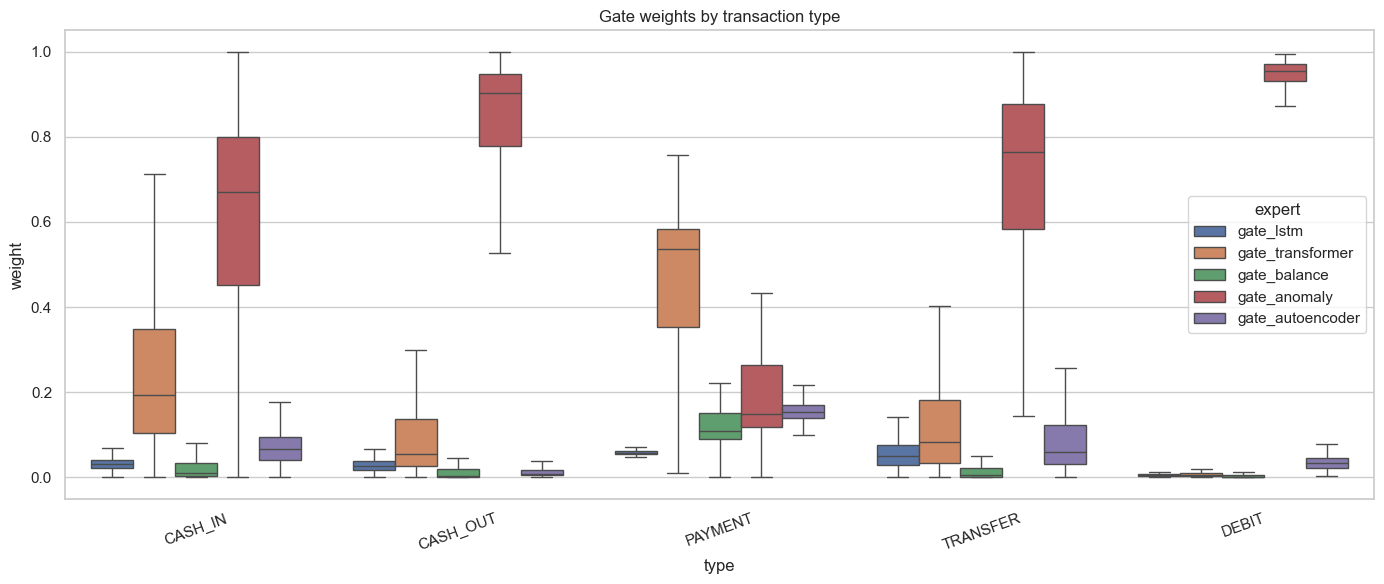

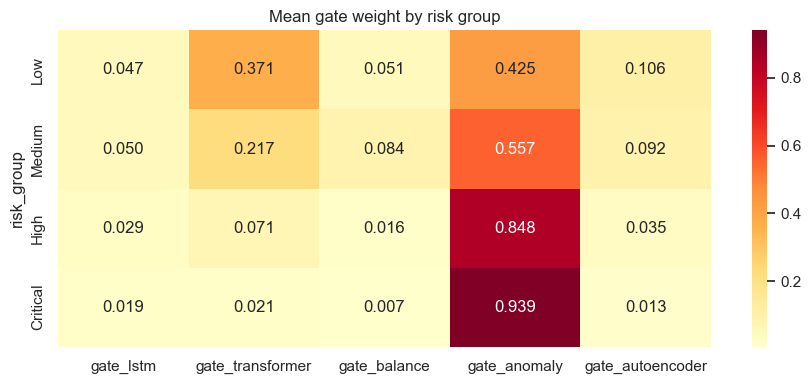

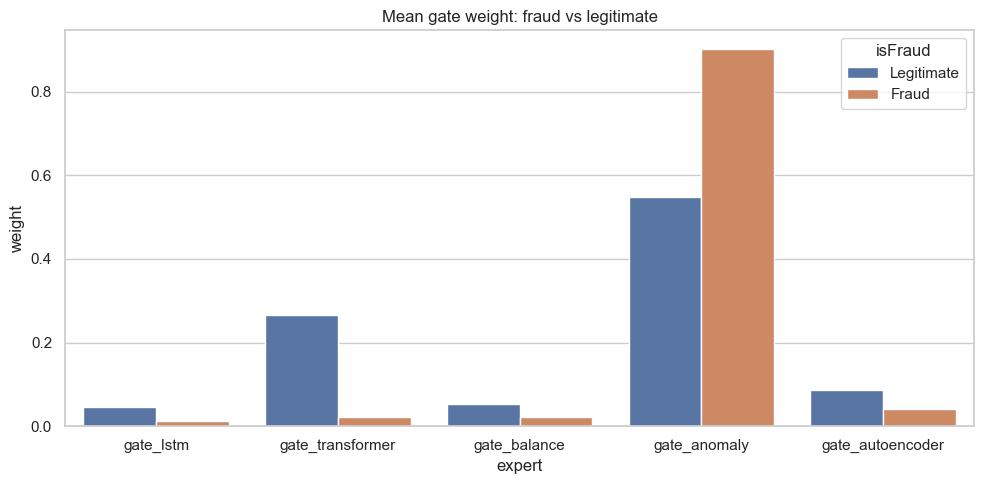

In [14]:
hybrid_score = test_scores["Hybrid MoE"]
q50, q80, q95 = np.quantile(hybrid_score, [0.50, 0.80, 0.95])
risk_group = pd.cut(
    hybrid_score, bins=[-np.inf, q50, q80, q95, np.inf],
    labels=["Low", "Medium", "High", "Critical"], include_lowest=True,
).astype(str)

gate_df = pd.DataFrame(test_gates, columns=EXPERT_GATE_COLUMNS)
gate_df.insert(0, "row_index", split_idx["test"])
gate_df["type"] = test_types
gate_df["isFraud"] = y_test
gate_df["risk_score"] = hybrid_score
gate_df["risk_group"] = risk_group
gate_df.to_csv(OUT_DIR / "gate_weights.csv", index=False)
np.save(OUT_DIR / "gate_weights.npy", test_gates)

rng = np.random.default_rng(RANDOM_STATE)
plot_gate = gate_df if len(gate_df) <= PLOT_SAMPLE_CAP else gate_df.iloc[rng.choice(len(gate_df), PLOT_SAMPLE_CAP, replace=False)]
gate_cols = EXPERT_GATE_COLUMNS
long_gate = plot_gate.melt(id_vars=["type", "isFraud", "risk_group"], value_vars=gate_cols, var_name="expert", value_name="weight")

plt.figure(figsize=(14, 6))
sns.boxplot(data=long_gate, x="type", y="weight", hue="expert", showfliers=False)
plt.xticks(rotation=20); plt.title("Gate weights by transaction type"); plt.tight_layout()
plt.savefig(FIG_DIR / "gate_boxplot_by_type.png", dpi=180); plt.show()

heat = gate_df.groupby("risk_group", observed=False)[gate_cols].mean().reindex(["Low", "Medium", "High", "Critical"])
plt.figure(figsize=(9, 4))
sns.heatmap(heat, annot=True, fmt=".3f", cmap="YlOrRd")
plt.title("Mean gate weight by risk group"); plt.tight_layout()
plt.savefig(FIG_DIR / "gate_heatmap_by_risk.png", dpi=180); plt.show()

fraud_gate = gate_df.groupby("isFraud")[gate_cols].mean().rename(index={0: "Legitimate", 1: "Fraud"}).reset_index()
fraud_long = fraud_gate.melt(id_vars="isFraud", var_name="expert", value_name="weight")
plt.figure(figsize=(10, 5))
sns.barplot(data=fraud_long, x="expert", y="weight", hue="isFraud")
plt.title("Mean gate weight: fraud vs legitimate"); plt.tight_layout()
plt.savefig(FIG_DIR / "gate_barplot_fraud_vs_legit.png", dpi=180); plt.show()


## 13. Xuất PR curve, ROC curve, confusion matrix từng model và so sánh PR-AUC.


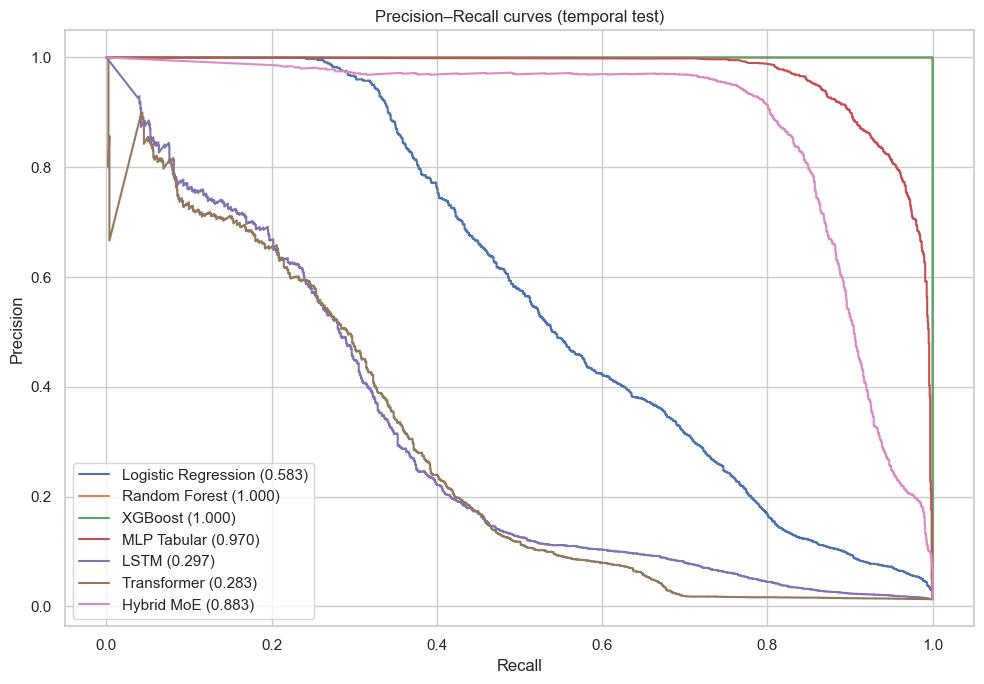

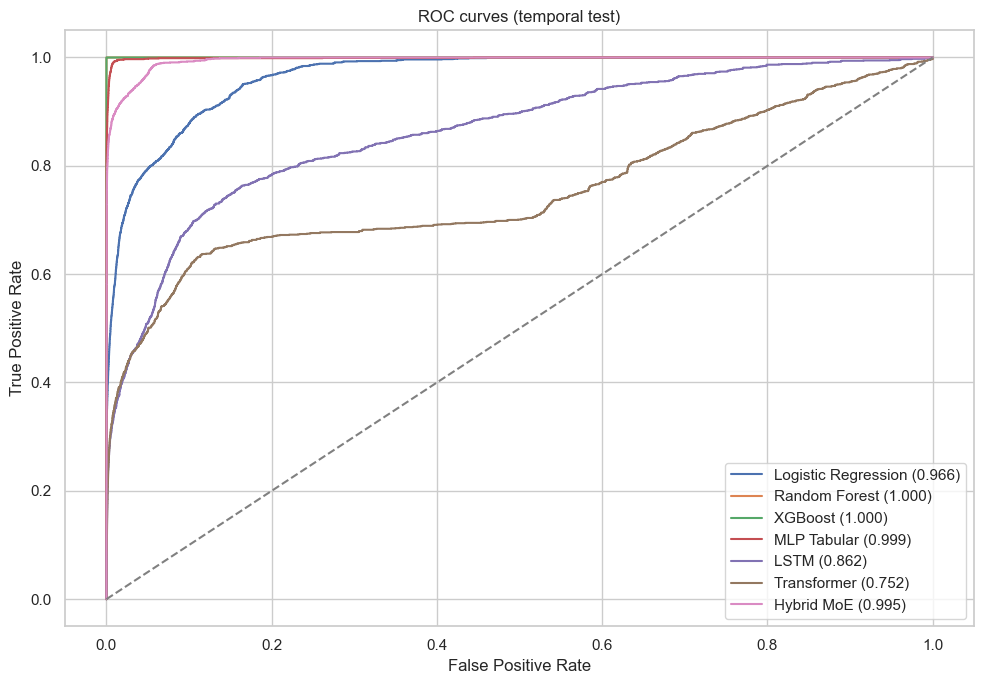

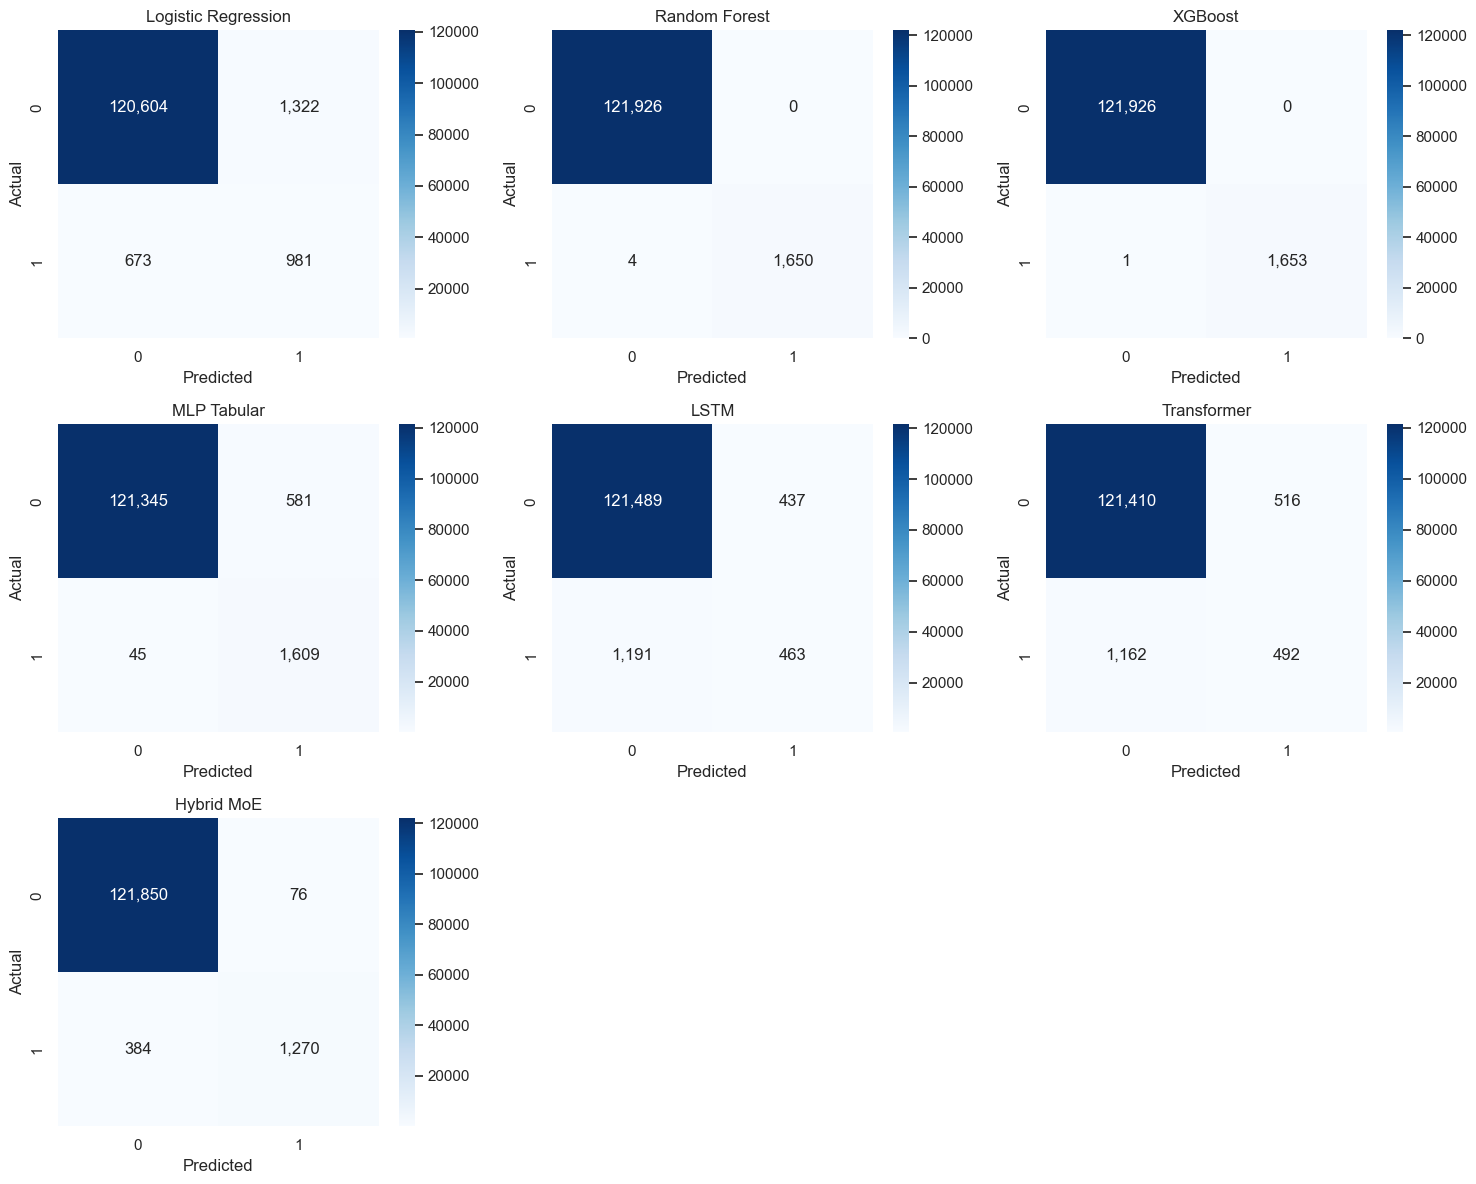

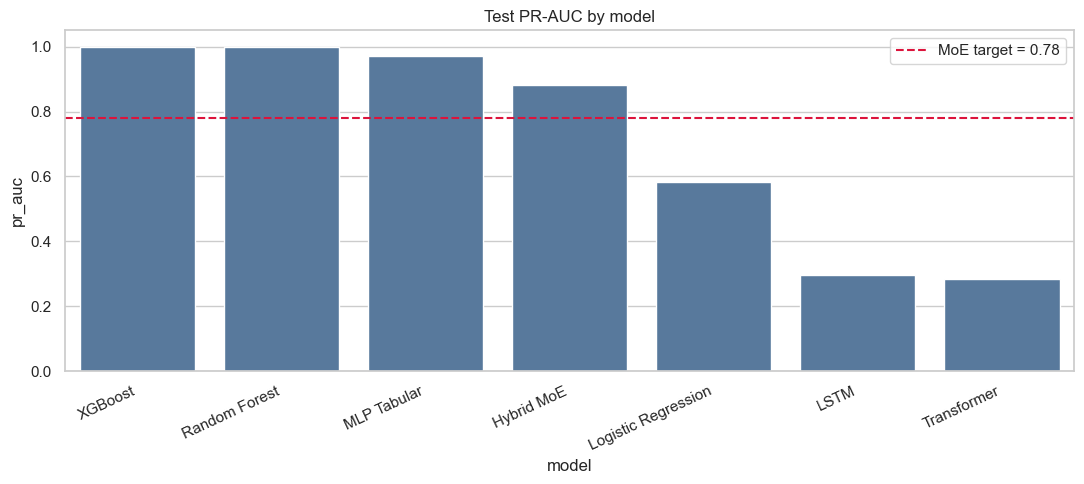

In [15]:
plt.figure(figsize=(10, 7))
for name, score in test_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, score)
    plt.plot(recall, precision, label=f"{name} ({average_precision_score(y_test, score):.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall curves (temporal test)")
plt.legend(); plt.tight_layout(); plt.savefig(FIG_DIR / "precision_recall_curves.png", dpi=180); plt.show()

plt.figure(figsize=(10, 7))
for name, score in test_scores.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    plt.plot(fpr, tpr, label=f"{name} ({roc_auc_score(y_test, score):.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC curves (temporal test)")
plt.legend(); plt.tight_layout(); plt.savefig(FIG_DIR / "roc_curves.png", dpi=180); plt.show()

fig, axes = plt.subplots(int(np.ceil(len(test_scores) / 3)), 3, figsize=(15, 4 * int(np.ceil(len(test_scores) / 3))))
axes = np.asarray(axes).reshape(-1)
for ax, (name, score) in zip(axes, test_scores.items()):
    pred = score >= thresholds[name]
    sns.heatmap(confusion_matrix(y_test, pred, labels=[0, 1]), annot=True, fmt=",d", cmap="Blues", ax=ax)
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
for ax in axes[len(test_scores):]: ax.axis("off")
plt.tight_layout(); plt.savefig(FIG_DIR / "confusion_matrices.png", dpi=180); plt.show()

plt.figure(figsize=(11, 5))
sns.barplot(data=metrics_df, x="model", y="pr_auc", color="#4C78A8")
plt.axhline(0.78, color="crimson", linestyle="--", label="MoE target = 0.78")
plt.xticks(rotation=25, ha="right"); plt.legend(); plt.title("Test PR-AUC by model")
plt.tight_layout(); plt.savefig(FIG_DIR / "model_pr_auc_comparison.png", dpi=180); plt.show()


## 14. Final check




In [16]:
TARGETS = {
    "accuracy": 0.991, "precision": 0.64, "recall": 0.75,
    "f1": 0.69, "pr_auc": 0.78, "roc_auc": 0.98,
    "recall_at_precision_0.80": 0.70,
}
hybrid = metrics_df.loc[metrics_df.model.eq("Hybrid MoE")].iloc[0]
target_check = pd.DataFrame([
    {"metric": metric, "actual": float(hybrid[metric]), "target": target, "passed": bool(hybrid[metric] >= target)}
    for metric, target in TARGETS.items()
])

print("=== MODEL COMPARISON ===")
display(metrics_df[["model", "accuracy", "precision", "recall", "f1", "pr_auc", "roc_auc", "recall_at_precision_0.80", "threshold"]])
print("=== HYBRID MoE TARGET CHECK ===")
display(target_check)
print("Outputs:", OUT_DIR)
print("Figures:", FIG_DIR)
print("All targets passed:", bool(target_check.passed.all()))


=== MODEL COMPARISON ===


,model,accuracy,precision,recall,f1,pr_auc,roc_auc,recall_at_precision_0.80,threshold
0,XGBoost,0.999992,1.000000,0.999395,0.999698,1.000000,1.000000,1.000000,0.999848
1,Random Forest,0.999968,1.000000,0.997582,0.998789,0.999998,1.000000,1.000000,0.705147
2,MLP Tabular,0.994934,0.734703,0.972793,0.837149,0.969958,0.999022,0.955865,0.999254
3,Hybrid MoE,0.996278,0.943536,0.767836,0.846667,0.883021,0.995151,0.849456,0.992391
4,Logistic Regression,0.983857,0.425966,0.593108,0.495830,0.583330,0.966136,0.377872,0.895910
5,LSTM,0.986826,0.514444,0.279927,0.362569,0.296769,0.862473,0.079807,0.982904
6,Transformer,0.986422,0.488095,0.297461,0.369647,0.282671,0.751668,0.081620,0.950902


=== HYBRID MoE TARGET CHECK ===


,metric,actual,target,passed
0,accuracy,0.996278,0.991,True
1,precision,0.943536,0.640,True
2,recall,0.767836,0.750,True
3,f1,0.846667,0.690,True
4,pr_auc,0.883021,0.780,True
5,roc_auc,0.995151,0.980,True
6,recall_at_precision_0.80,0.849456,0.700,True


Outputs: C:\Users\ADMIN\Downloads\DAP391m_Report_Group3\model_results
Figures: C:\Users\ADMIN\Downloads\DAP391m_Report_Group3\model_results\figures
All targets passed: True
